# diffusion modeling for 21cmfast & camels


## What is this notebook?

This notebook explores **diffusion models** applied to cosmological simulation data from the [CAMELS](https://camels.readthedocs.io) project. The goal is to train a model that can *generate new, realistic density field images* that look statistically like the real simulations — a powerful tool for data augmentation and for understanding what the model has learned about cosmological structure.

We go through three main stages:
1. **Load and preprocess** the simulation data
2. **Train a DDPM diffusion model** (a type of generative model based on iterative denoising)
3. **Evaluate the samples** using power spectra and embedding-based visualisation

No prior knowledge of diffusion models is assumed — each section explains the key ideas from scratch.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn import metrics
import os
import h5py

import time

In [2]:
# import sys
# !{sys.executable} -m pip install --user --force-reinstall \
#     "numpy==1.26.4" \
#     "scipy==1.10.1"

In [3]:
torch.set_default_dtype(torch.float32)

In [4]:
# pip install torch --upgrade

## 1. Setup

We set `float32` as the default numeric precision — this is standard for deep learning (it balances speed and accuracy). We also choose the **compute device**:
- `'cpu'` — always available, but slow for large models
- `'cuda'` — NVIDIA GPU (fastest, use this on Great Lakes)
- `'mps'` — Apple Silicon GPU

On Great Lakes you'll want `device = 'cuda'` to take advantage of the GPU nodes.

In [5]:
# can toggle between CPU, Apple-GPU, NVIDIA-GPU
device = 'cpu'

torch.set_default_device(device)

In [6]:
# load 21cmfast data
# (Nbatch, Nx, Ny, Nz)
#with h5py.File('IonizedBox_z8.00000000_r43868.h5') as f:
#    data = torch.as_tensor(f['IonizedBox']['xH_box'][:][None]).to(torch.float32)

## 2. Load & Preprocess CAMELS Data

**What is CAMELS?** The Cosmology and Astrophysics with MachinE Learning Simulations suite runs thousands of N-body + hydrodynamics simulations, each with slightly different cosmological parameters (like the amount of dark matter, or how energetic supernova feedback is). This makes it ideal for ML — lots of diverse but physically meaningful examples.

**What's in the file?** Each simulation produces a 3D dark matter density grid of shape `(128, 128, 128)`. We treat each 2D *z-slice* as an independent training image, giving us a large dataset of `(1, 128, 128)` images.

**Why log-transform?** The dark matter density spans many orders of magnitude — filaments and voids differ by factors of millions. Taking `log` compresses this range and makes the distribution much more Gaussian-like, which is much easier for a neural network to model.

**Why normalise?** We centre and scale the data to lie roughly in `[-1, 1]`. Neural networks train much more stably when inputs are in this range.

In [7]:
# load camels data: 8 GB
# (Nbatch, Nx, Ny, Nz)
data = torch.as_tensor(np.load('small_Grids_Mcdm_IllustrisTNG_LH_128_z=0.0.npy')[:, :, :, :]).to(device).log()
data_center = data.mean()
data_scale = (data - data_center).abs().max()
data = (data.reshape(-1, 1, data.shape[-2], data.shape[-1]) - data_center) / data_scale
X_train = data[len(data)//5:]
X_test = data[:len(data)//5]

In [40]:
d = np.load('small_Grids_Mcdm_IllustrisTNG_LH_128_z=0.0.npy')
print(d.shape)
# → (34, 128, 128, 128)

(34, 128, 128, 128)


### Quick data inspection

Before training anything, always look at your data. The histogram shows the distribution of pixel values after log-normalisation — it should look roughly bell-shaped. The image shows what a single 2D density slice looks like: bright regions are dense filaments, dark regions are cosmic voids.

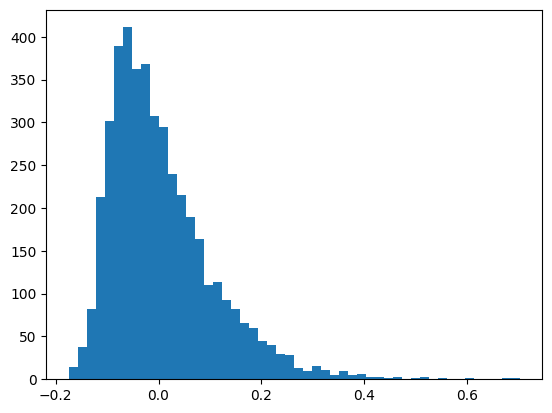

In [8]:
plt.hist(data[:, 0,30,0].cpu(), bins=50);

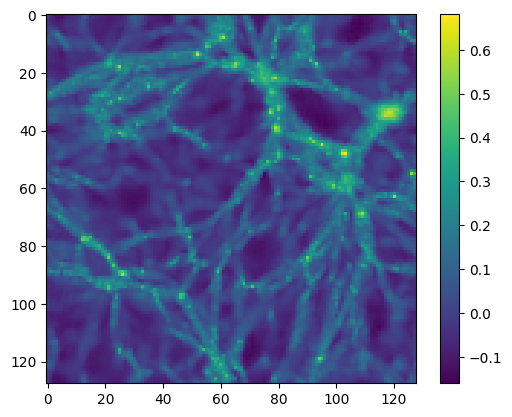

In [9]:
plt.imshow(data[1550,0].cpu(), interpolation='none'); plt.colorbar();

In [10]:
# import sys
# !{sys.executable} -m pip install "huggingface_hub==0.23.4" "diffusers==0.27.2" --force-reinstall --user

In [11]:
# import sys
# !{sys.executable} -m pip install --user --force-reinstall \
#     "huggingface_hub==0.25.2" \
#     "diffusers==0.27.2" \
#     "transformers==4.44.2"

In [12]:
# import diffusers, transformers, huggingface_hub
# print("diffusers:", diffusers.__version__)
# print("transformers:", transformers.__version__)
# print("huggingface_hub:", huggingface_hub.__version__)

# from huggingface_hub import cached_download
# from diffusers import UNet2DModel, DDPMScheduler, DDPMPipeline

In [13]:
# import sys
# !{sys.executable} -m pip install --user torchvision

## 3. Diffusion Model — Core Idea

**What is a diffusion model?**

Imagine taking a beautiful photograph and slowly adding random static (Gaussian noise) to it, step by step, until it looks like pure TV static. That's the **forward process**. A diffusion model learns to reverse this — given a noisy image and the noise level, it predicts what the noise looks like so it can be subtracted, gradually revealing a clean image.

At inference time, we start from *pure random noise* and run the reverse process from scratch, producing a brand new image that was never in the training set but looks statistically similar to real training data.

**Why is this useful for cosmology?**  
We can generate arbitrarily many synthetic density field realisations — useful for covariance estimation, data augmentation, or just checking that the model has learned the right statistics (power spectrum, non-Gaussianities, etc.).

We use the **Hugging Face `diffusers` library**, which provides ready-made building blocks: the UNet noise-prediction network and the DDPM noise scheduler.

In [14]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from diffusers import UNet2DModel, DDPMScheduler, DDPMPipeline
from torchvision import datasets, transforms

## UNet2DModel Architecture

This is the noise-prediction network at the heart of the DDPM. It follows the classic **UNet** design: a contracting path (encoder) that downsamples the spatial resolution while expanding the channel depth, a bottleneck, and then a symmetric expanding path (decoder) that upsamples back to the original resolution. **Skip connections** pass feature maps from each encoder block directly to the matching decoder block, giving the decoder access to fine-grained spatial detail that would otherwise be lost during downsampling.

### Channel progression

```
Input (1ch, 128×128)
    │
    ▼ conv_in
   64ch, 128×128  ──→  DownBlock2D      (ResNet only)
  128ch,  64×64   ──→  DownBlock2D      (ResNet only)          ┐ skip connections
  256ch,  32×32   ──→  AttnDownBlock2D  (ResNet + attention)   │ cached here,
  512ch,  16×16   ──→  DownBlock2D      (ResNet only)          │ injected on
                            ↕  bottleneck (512ch, 16×16)       │ the way up
  512ch,  16×16   ──→  UpBlock2D        (ResNet + skip)        │
  256ch,  32×32   ──→  AttnUpBlock2D    (ResNet + attn + skip) │
  128ch,  64×64   ──→  UpBlock2D        (ResNet + skip)        │
   64ch, 128×128  ──→  UpBlock2D        (ResNet + skip)        ┘
    │
    ▼ conv_out
Output (1ch, 128×128)  ← predicted noise ε
```

### Key design choices

**`in_channels=1` and `out_channels=1`** — both match the single-channel density field. The model takes a noisy image and outputs a tensor of the *same shape*: the predicted noise `ε`. This is the standard DDPM parameterisation — the loss is just `MSE(ε_pred, ε_true)`.

**`block_out_channels=(64, 128, 256, 512)`** — channels double at each scale, which is standard. More channels = more expressive features at coarser resolution, where the model needs to reason about large-scale structure.

**Attention only at the 256ch (32×32) level** — self-attention scales as O(N²) in the number of spatial tokens, so it's too expensive at full resolution. By the 32×32 level the spatial map is small enough that attention is affordable, and the model can learn long-range correlations (important for capturing the large-scale structure of the cosmic web).

**Timestep conditioning** — the diffusion timestep `t` is sinusoidally embedded and injected into every ResNet block via a learned affine transform (FiLM conditioning). This tells the network how noisy its input is, so it can adapt the strength and style of its denoising.

**Skip connections** are handled automatically inside `UNet2DModel` — you don't wire them up manually. Each `DownBlock` pushes its output onto a stack; each `UpBlock` pops and concatenates before its convolutions.

In [15]:
model = UNet2DModel(
    sample_size=128,           # Target image resolution
    in_channels=1,            # Input channels (e.g., 3 for RGB)
    out_channels=1,           # Output channels
    layers_per_block=2,       # ResNet layers per UNet block
    block_out_channels=(64, 128, 256, 512), 
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D"
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D"
    ),
).to(device)

### Noise Scheduler

The `DDPMScheduler` controls *how much noise* is added at each timestep during training, and how it's removed during sampling. Think of it as a recipe: "at step 10, the image should be 10% noisy; at step 90, it should be 90% noisy."

`num_train_timesteps=100` means we use a 100-step noising chain. The standard in the original DDPM paper is 1000 steps (higher quality but slower to train and sample). 100 is a good starting point for experimentation.

In [16]:
noise_scheduler = DDPMScheduler(num_train_timesteps=100)

## 4. Data Pipeline

We set up standard PyTorch data loading. A few things to note:

**Augmentations**: Random horizontal and vertical flips are applied. This is valid here because the cosmic density field is statistically **isotropic** — there's no preferred direction in the universe, so a flipped density field is just as physically valid as the original. This effectively doubles (or quadruples) the training data for free.

> ⚠️ Note: the `transform` object is defined here but isn't actually wired into the `TensorDataset` below — so flips aren't being applied in the current code. To use them you'd need a custom `Dataset` class that applies the transform on `__getitem__`.

**DataLoader**: `batch_size=10` means the model sees 10 images per gradient update. Larger batches are more stable but require more GPU memory.

In [17]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
])

In [18]:
dataset = torch.utils.data.TensorDataset(X_train)

In [19]:
generator = torch.Generator(device=device)
dataloader = torch.utils.data.DataLoader(dataset, shuffle=True, batch_size=10, generator=generator)

In [20]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

## 5. Training Loop

This is the heart of DDPM training. Each iteration does the following:

1. **Sample a batch** of real, clean density field images `x_0`
2. **Sample random noise** `ε ~ N(0, I)` — standard Gaussian noise, same shape as the images
3. **Sample random timesteps** `t` — each image in the batch gets a different noise level
4. **Corrupt the images** using the closed-form noising equation (see below)
5. **Predict the noise**: the UNet sees the noisy image `x_t` and the timestep `t`, and tries to predict `ε`
6. **Compute the loss**: just MSE between predicted and actual noise — `loss = ||ε_pred - ε||²`
7. **Backpropagate** and update the weights

> 💡 `if step > 4: break` limits each epoch to just 5 batches — fine for testing, but remove this for real training on Great Lakes.

---

### The noising equation — and why it only takes one step

You might expect that to get a "timestep 80" noisy image, you'd have to simulate all 80 steps one by one:

```
x_0 → x_1 → x_2 → ... → x_80
```

applying a little noise at each step. That would be extremely slow during training.

**There's a shortcut.** Each individual noising step adds a small amount of Gaussian noise:

```
x_t = sqrt(α_t) · x_{t-1}  +  sqrt(1 - α_t) · ε_t
```

where `α_t = 1 - β_t` and `β_t` is a small scheduled noise level. If you expand this recursively — substituting `x_{t-1}` in terms of `x_{t-2}`, then `x_{t-2}` in terms of `x_{t-3}`, all the way back to `x_0` — all the intermediate Gaussian noise terms **collapse into a single Gaussian**. This works because the sum of independent Gaussians is itself a Gaussian.

After the algebra, you get:

```
x_t = sqrt(ᾱ_t) · x_0  +  sqrt(1 - ᾱ_t) · ε
```

where:
- `ε ~ N(0, I)` is just **one** noise sample (not 80 separate ones)
- `ᾱ_t = α_1 · α_2 · ... · α_t` is the product of all alphas up to step `t`, **precomputed once** at the start
- `sqrt(ᾱ_t)` controls how much of the **clean image** survives (close to 1 at small `t`, close to 0 at large `t`)
- `sqrt(1 - ᾱ_t)` controls how much **noise** is mixed in (the opposite)

So during training, to corrupt any image to any noise level `t`, you just look up the precomputed `ᾱ_t` and do one weighted sum. This is what `noise_scheduler.add_noise(clean_images, noise, timesteps)` does under the hood.

In [21]:
model.train()
startt = time.time()

for epoch in range(15):
    for step, (clean_images, ) in enumerate(dataloader):
        noise = torch.randn_like(clean_images)

        bsz = clean_images.shape[0]
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (bsz,),
            dtype=torch.long,
        )

        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
        noise_pred = model(noisy_images, timesteps).sample

        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if step > 4: break
    print(f"epoch={epoch} step={step} loss={loss.item():.4f} elapsed={time.time()-startt:.1f} sec")

epoch=0 step=5 loss=0.2708 elapsed=56.6 sec
epoch=1 step=5 loss=0.1114 elapsed=111.6 sec
epoch=2 step=5 loss=0.0959 elapsed=166.0 sec
epoch=3 step=5 loss=0.1309 elapsed=220.3 sec
epoch=4 step=5 loss=0.0850 elapsed=274.6 sec
epoch=5 step=5 loss=0.0802 elapsed=328.5 sec
epoch=6 step=5 loss=0.0932 elapsed=383.9 sec
epoch=7 step=5 loss=0.0798 elapsed=440.4 sec
epoch=8 step=5 loss=0.0593 elapsed=497.8 sec
epoch=9 step=5 loss=0.0375 elapsed=555.2 sec
epoch=10 step=5 loss=0.0674 elapsed=614.0 sec
epoch=11 step=5 loss=0.1255 elapsed=671.7 sec
epoch=12 step=5 loss=0.1057 elapsed=730.1 sec
epoch=13 step=5 loss=0.0593 elapsed=788.9 sec
epoch=14 step=5 loss=0.0423 elapsed=846.8 sec


### Save the Model

We save the trained UNet and scheduler using Hugging Face's `save_pretrained` format. This creates a directory containing:
- `config.json` — model architecture hyperparameters
- `diffusion_pytorch_model.safetensors` — the actual learned weights

This can be reloaded later with `UNet2DModel.from_pretrained(save_dir)`.

In [22]:
# -----------------
# Save
# -----------------
save_dir = "./"
os.makedirs(save_dir, exist_ok=True)
model.save_pretrained(save_dir)
noise_scheduler.save_pretrained(save_dir)

print(f"Saved model to {save_dir}")

Saved model to ./


In [23]:
# load model if needed
load_model = False
if load_model:
    os.makedirs("./", exist_ok=True)
    model = UNet2DModel.from_pretrained(model_dir).to(device)
    noise_scheduler = DDPMScheduler.from_pretrained(model_dir)

## 6. Generate New Samples

Now we run the **reverse diffusion process** to generate brand new density field images from scratch.

We start with pure Gaussian noise `x_T ~ N(0, I)` and iteratively denoise it, stepping backwards through all `T` timesteps:

```
for t in [T, T-1, ..., 1, 0]:
    ε_pred = UNet(x_t, t)          # predict the noise
    x_{t-1} = scheduler.step(...)  # subtract predicted noise → slightly cleaner image
```

After `T` steps, `x_0` should look like a plausible density field. The key insight: **we never looked at any real image during sampling** — everything came from noise, shaped by what the model learned.

In [24]:
# Start from Gaussian noise
sample_size = model.config.sample_size
in_channels = model.config.in_channels
num_samples = 5
x = torch.randn(num_samples, 1, 128, 128, device=device)

model.eval()

startt = time.time()
with torch.no_grad():
    for t in noise_scheduler.timesteps:
        noise_pred = model(x, t).sample
        x = noise_scheduler.step(noise_pred, t, x).prev_sample
print(f"elapsed={time.time()-startt:.2f} sec")

elapsed=116.68 sec


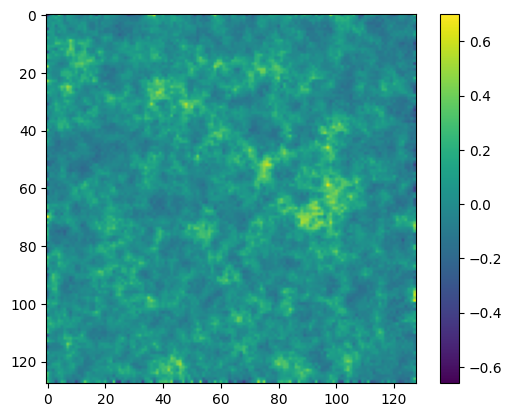

In [25]:
plt.imshow(x[3,0].cpu()); plt.colorbar();

## 7. Baseline: PCA / SVD Samples

Before trusting the diffusion model, it helps to compare against a simple baseline. Here we use **PCA** (Principal Component Analysis, computed via SVD).

The idea: find the main "modes of variation" in the training data, then sample random combinations of those modes (weighted by how much variance each mode explains). This is essentially a linear generative model.

PCA samples will look **blurry** — they capture large-scale structure but miss small-scale non-Gaussian features (filaments, voids, halos). If our diffusion model is doing its job, its samples should look sharper and more realistic than these.

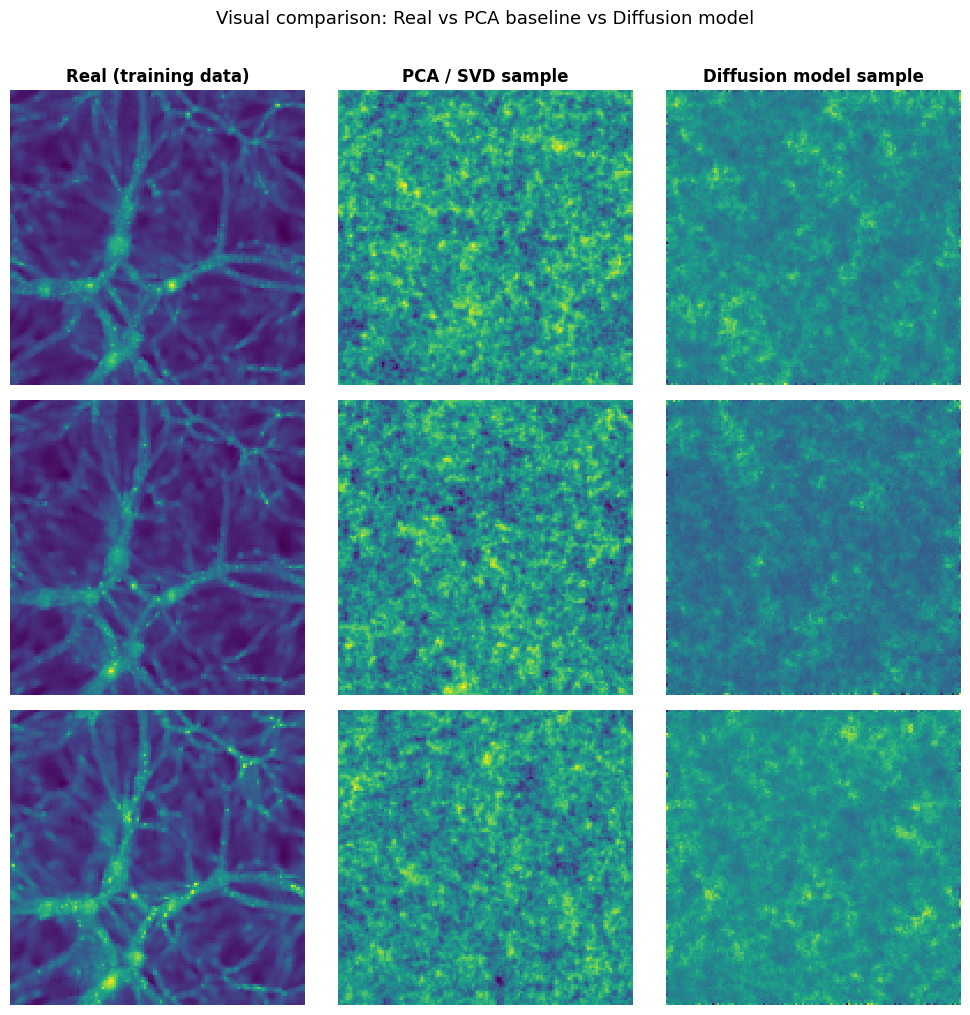

In [39]:
U, S, V = torch.linalg.svd(X_train[:2000].reshape(-1, 128**2), full_matrices=False)
x2 = (torch.randn(3, 1, 2000) @ (S.sqrt().unsqueeze(-1) * V)).reshape(3, 1, 128, 128)

# Compare: real data vs PCA samples vs diffusion samples (x)
# x was generated in the sampling cell above
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

titles = ['Real (training data)', 'PCA / SVD sample', 'Diffusion model sample']
sources = [X_train, x2, x]

for col, (title, source) in enumerate(zip(titles, sources)):
    for row in range(3):
        axes[row, col].imshow(source[row, 0].cpu().detach(), interpolation='none')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Visual comparison: Real vs PCA baseline vs Diffusion model', y=1.01, fontsize=13)
plt.tight_layout()

# What to look for:
# - PCA samples: no coherent filaments, just pixel-level noise — the linear
#   model can't capture the non-Gaussian structure of the cosmic web
# - Diffusion samples: should show filament-like structure closer to real data
#   (especially after proper full training — this is only 15 epochs x 5 batches)

## 8. Power Spectrum Evaluation

The **power spectrum P(k)** is the fundamental two-point statistic in cosmology. It tells you: for structures of scale `1/k`, how much density fluctuation power is there?

- Small `k` = large scales (clusters, voids)
- Large `k` = small scales (halos, filaments)

A good generative model should reproduce the training data's P(k) at all scales. If the diffusion samples have too little power at large `k`, the images look too smooth. If they have too much, they look too noisy.

We use `powerbox.get_power` to compute P(k) for each training slice and plot the ensemble — the spread of black lines shows the natural variation between different simulation slices.

In [30]:
import sys
!{sys.executable} -m pip install powerbox --user -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [31]:
from powerbox import get_power

In [32]:
kbins = get_power(X_train[0,0].cpu(), 25)[1]
p_k_train = np.array([get_power(_x.cpu(), 25)[0] for _x in X_train[:10, 0]])
p_k_sample = np.array([get_power(_x.cpu(), 25)[0] for _x in x[:10, 0]])

/home/jiamingp/.local/lib/python3.10/site-packages/powerbox/tools.py:261: FutureWarning: In the future, bins will be generated by default up to the smallest length over any dimension, instead of the largest magnitude for the box.Set bins_upto_boxlen to silence this warning.
  bins = _getbins(bins, coord_mags, log_bins, bins_upto_boxlen=bins_upto_boxlen)


In [33]:
kbins = get_power(X_train[0,0].cpu(), 25)[1]
p_k_train = np.array([get_power(_x.cpu(), 25)[0] for _x in X_train[::50, 0]])

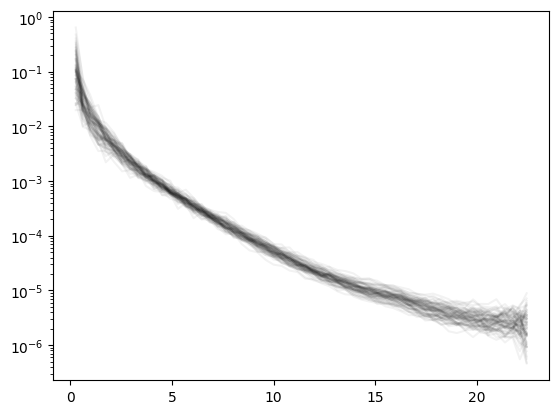

In [34]:
plt.plot(kbins, p_k_train.T, c='k', alpha=.05)
#plt.plot(kbins, p_k_sample.T, c='indianred', alpha=.2)
plt.yscale('log')

## 9. Perceptual Evaluation with DINOv2 + t-SNE

The power spectrum only captures **two-point statistics** (how pixels correlate in pairs). But the cosmic density field has rich **higher-order structure** — the cosmic web has filaments, sheets, and voids arranged in complex patterns that P(k) alone can't capture.

To evaluate this, we use **DINOv2** — a powerful Vision Transformer (ViT) model trained by Meta on 142 million natural images using self-supervised learning. Its internal representations capture rich perceptual structure: texture, shape, spatial patterns. Even though it was trained on photos of cats and cars, it transfers surprisingly well to scientific images.

**The plan:**
1. Pass training images through DINOv2 → get a 768-dimensional "fingerprint" for each image
2. Project those fingerprints to 2D using **t-SNE** for visualisation
3. Do the same for diffusion-generated samples → if they land in the same region of the t-SNE plot as training data, the model has learned the right distribution

Here we embed two subsets of training data with different orientations (original vs. vertically flipped) as a sanity check — since the field is isotropic, both should look identical in embedding space.

In [35]:
# download an image embedding model
dinov2_vitb14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /home/jiamingp/.cache/torch/hub/main.zip


/home/jiamingp/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/jiamingp/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/jiamingp/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /home/jiamingp/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:02<00:00, 117MB/s]  


In [36]:
with torch.no_grad():
    emb1 = dinov2_vitb14(torch.repeat_interleave(X_train[::3, :, 1:-1, 1:-1], 3, dim=1))
    emb2 = dinov2_vitb14(torch.repeat_interleave(X_train[1::3, :, 1:-1, 1:-1].flip(-2), 3, dim=1))

### t-SNE: What was wrong and what we fixed

The original code had several issues that made the plot misleading or poorly converged. Here's exactly what changed:

---

**❌ Before: Two separate t-SNE fits**
```python
tsne1 = TSNE(...).fit_transform(emb1)
tsne2 = TSNE(...).fit_transform(emb2)
```
t-SNE coordinates are completely arbitrary — each run produces its own independent 2D coordinate system. Overlaying the two scatter plots is like overlaying two maps drawn at different scales and rotations. The relative positions between blue and orange points meant nothing.

**✅ After: One joint fit**
```python
emb_all = np.concatenate([emb1, emb2], axis=0)
tsne_all = TSNE(...).fit_transform(emb_all)
```
Both groups are embedded together in a single run, so they genuinely share the same coordinate space and can be meaningfully compared.

---

**❌ Before: `perplexity=3`**  
Perplexity controls how many neighbours each point "pays attention to" when arranging itself in 2D. With `perplexity=3`, each point only looks at its 3 nearest neighbours and ignores all global structure — this produces the scattered blob-of-blobs pattern you saw, where points clump into tiny isolated islands with no meaningful layout.

**✅ After: `perplexity = min(30, N//10)`**  
The standard recommendation is perplexity between 5 and 50, with `~sqrt(N)` or `N//10` as a rule of thumb. Around 30 gives a good balance between local and global structure.

---

**❌ Before: Default `n_iter=300`**  
t-SNE is an iterative optimisation. 300 iterations is often not enough for the layout to converge — the points are still slowly drifting when the algorithm stops.

**✅ After: `n_iter=1000`**  
Gives the optimisation enough time to settle into a stable configuration.

---

**➕ Added: `random_state=42`**  
Makes the result reproducible — without this, you get a different plot every run, which makes it hard to compare across experiments.

In [37]:
import numpy as np
from sklearn.manifold import TSNE

# ── Why joint fit? ──────────────────────────────────────────────────────────
# t-SNE is not deterministic and its coordinates are arbitrary — two separate
# runs produce completely different coordinate systems. Overlaying them is
# meaningless. We concatenate both embedding sets and fit t-SNE *once* so
# both groups share the same 2D space.

n1 = emb1.shape[0]
emb_all = np.concatenate([emb1.cpu().numpy(), emb2.cpu().numpy()], axis=0)

# ── Perplexity ─────────────────────────────────────────────────────────────
# Perplexity ≈ the number of "effective neighbours" each point considers.
# Rule of thumb: between 5 and 50; sqrt(N) is a reasonable default.
# Too low → scattered isolated blobs. Too high → everything collapses together.
perplexity = min(30, max(5, emb_all.shape[0] // 10))

tsne = TSNE(
    n_components=2,
    learning_rate='auto',
    init='pca',           # PCA init is more stable than random
    perplexity=perplexity,
    n_iter=1000,          # default 300 is often not enough; 1000 is safer
    random_state=42,      # reproducibility
)
tsne_all = tsne.fit_transform(emb_all)

tsne1 = tsne_all[:n1]   # original orientation embeddings
tsne2 = tsne_all[n1:]   # vertically flipped embeddings
print(f"t-SNE done. perplexity={perplexity}, n_samples={len(emb_all)}")

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x149b273e0700>
Traceback (most recent call last):
  File "/sw/pkgs/arc/python3.10-anaconda/2023.03/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/sw/pkgs/arc/python3.10-anaconda/2023.03/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/sw/pkgs/arc/python3.10-anaconda/2023.03/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/sw/pkgs/arc/python3.10-anaconda/2023.03/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


t-SNE done. perplexity=30, n_samples=2322


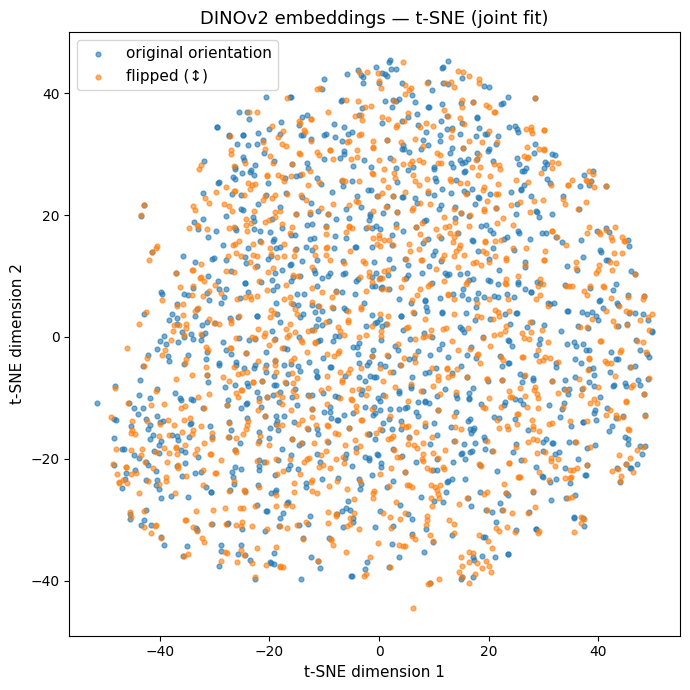

In [38]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(*tsne1.T, s=12, alpha=0.6, label='original orientation')
ax.scatter(*tsne2.T, s=12, alpha=0.6, label='flipped (↕)')
ax.legend(fontsize=11)
ax.set_title('DINOv2 embeddings — t-SNE (joint fit)', fontsize=13)
ax.set_xlabel('t-SNE dimension 1', fontsize=11)
ax.set_ylabel('t-SNE dimension 2', fontsize=11)
plt.tight_layout()

# ── How to read this plot ───────────────────────────────────────────────────
# - Each point is one density field image, projected to 2D from 768-dim space
# - Points that are close together have similar visual/structural features
# - If blue and orange mix uniformly → flips are indistinguishable (expected
#   for an isotropic field like the cosmic web) ✓
# - If they cluster separately → the model sees a directional asymmetry (bad)
# - Later: add generated samples in a third colour to see if they overlap

In [ ]:
# (duplicate of plot above — removed)